# Lab Instructions

Find a dataset that interests you. I'd recommend starting on [Kaggle](https://www.kaggle.com/). Read through all of the material about the dataset and download a .CSV file.

1. Write a short summary of the data.  Where did it come from?  How was it collected?  What are the features in the data?  Why is this dataset interesting to you?  

2. Identify 5 interesting questions about your data that you can answer using Pandas methods.  

3. Answer those questions!  You may use any method you want (including LLMs) to help you write your code; however, you should use Pandas to find the answers.  LLMs will not always write code in this way without specific instruction.  

4. Write the answer to your question in a text box underneath the code you used to calculate the answer.



## Dataset Used

For this lab, I used the file `anime-dataset-2023.csv` from Kaggle.

## Dataset Description

For this lab, I used the file `anime-dataset-2023.csv`, which contains information about 24,905 anime entries. The dataset includes columns such as anime title, score, genres, type, number of episodes, aired dates, studios, source material, favorites, members, and more.

I chose this dataset because anime is a topic that interests me personally, and it also gives a good mix of categorical and numeric variables for analysis. That makes it useful for practicing Pandas skills such as cleaning data, grouping rows, splitting text columns, creating new categories, and making visualizations.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("anime-dataset-2023.csv")
df.head()


,anime_id,Name,English name,Other name,Score,Genres,Synopsis,Type,Episodes,Aired,...,Studios,Source,Duration,Rating,Rank,Popularity,Favorites,Scored By,Members,Image URL
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,8.75,"Action, Award Winning, Sci-Fi","Crime is timeless. By the year 2071, humanity ...",TV,26.0,"Apr 3, 1998 to Apr 24, 1999",...,Sunrise,Original,24 min per ep,R - 17+ (violence & profanity),41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,8.38,"Action, Sci-Fi","Another day, another bounty—such is the life o...",Movie,1.0,"Sep 1, 2001",...,Bones,Original,1 hr 55 min,R - 17+ (violence & profanity),189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...
2,6,Trigun,Trigun,トライガン,8.22,"Action, Adventure, Sci-Fi","Vash the Stampede is the man with a $$60,000,0...",TV,26.0,"Apr 1, 1998 to Sep 30, 1998",...,Madhouse,Manga,24 min per ep,PG-13 - Teens 13 or older,328.0,246,15035,356739.0,727252,https://cdn.myanimelist.net/images/anime/7/203...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),7.25,"Action, Drama, Mystery, Supernatural",Robin Sena is a powerful craft user drafted in...,TV,26.0,"Jul 3, 2002 to Dec 25, 2002",...,Sunrise,Original,25 min per ep,PG-13 - Teens 13 or older,2764.0,1795,613,42829.0,111931,https://cdn.myanimelist.net/images/anime/10/19...
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,6.94,"Adventure, Fantasy, Supernatural",It is the dark century and the people are suff...,TV,52.0,"Sep 30, 2004 to Sep 29, 2005",...,Toei Animation,Manga,23 min per ep,PG - Children,4240.0,5126,14,6413.0,15001,https://cdn.myanimelist.net/images/anime/7/215...


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24905 entries, 0 to 24904
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   anime_id      24905 non-null  int64 
 1   Name          24905 non-null  object
 2   English name  24905 non-null  object
 3   Other name    24905 non-null  object
 4   Score         24905 non-null  object
 5   Genres        24905 non-null  object
 6   Synopsis      24905 non-null  object
 7   Type          24905 non-null  object
 8   Episodes      24905 non-null  object
 9   Aired         24905 non-null  object
 10  Premiered     24905 non-null  object
 11  Status        24905 non-null  object
 12  Producers     24905 non-null  object
 13  Licensors     24905 non-null  object
 14  Studios       24905 non-null  object
 15  Source        24905 non-null  object
 16  Duration      24905 non-null  object
 17  Rating        24905 non-null  object
 18  Rank          24905 non-null  object
 19  Popu

## Data Cleaning

Before answering the questions, I converted a few columns to numeric format because some values were stored as text such as `UNKNOWN`. This makes it easier to calculate averages and create visualizations.


In [3]:
anime = df.copy()

for col in ["Score", "Episodes", "Scored By", "Rank"]:
    anime[col] = pd.to_numeric(anime[col], errors="coerce")

anime[["Score", "Episodes", "Scored By", "Rank"]].isna().sum()


Score        9213
Episodes      611
Scored By    9213
Rank         4612
dtype: int64

## Question 1

Which anime type has the highest average score?


         Average_Score  Count
Type                         
TV            6.847144   4482
Special       6.365714   2039
Movie         6.344137   2475
OVA           6.217557   3283
ONA           6.038212   1929
Music         5.861470   1483


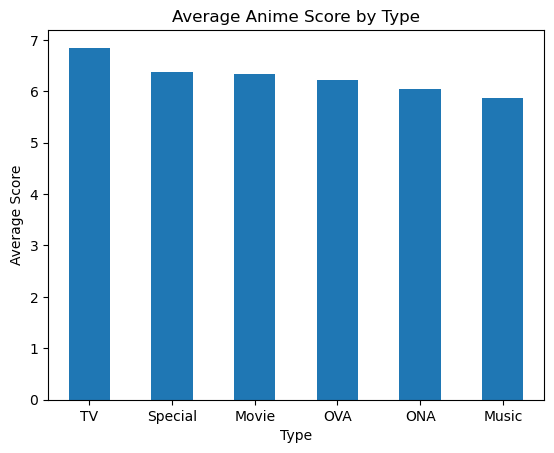

In [4]:
type_scores = (
    anime.dropna(subset=["Score"])
    .query("Type != 'UNKNOWN'")
    .groupby("Type")
    .agg(Average_Score=("Score", "mean"), Count=("Score", "count"))
    .sort_values("Average_Score", ascending=False)
)

print(type_scores)

type_scores["Average_Score"].plot(kind="bar", title="Average Anime Score by Type")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()


### Answer 1

TV anime had the highest average score in this dataset at about **6.85**, followed by specials and movies. Music anime had the lowest average score among the major types. This suggests that TV series tend to receive stronger ratings overall, possibly because they usually have more time to build story, characters, and audience attachment than shorter formats.


## Question 2

What are the most common anime genres in the dataset?


Genres
Comedy           7142
Fantasy          5306
Action           4730
Adventure        3842
Sci-Fi           3091
Drama            2836
Romance          2063
Slice of Life    1755
Supernatural     1494
Hentai           1486
Name: count, dtype: int64


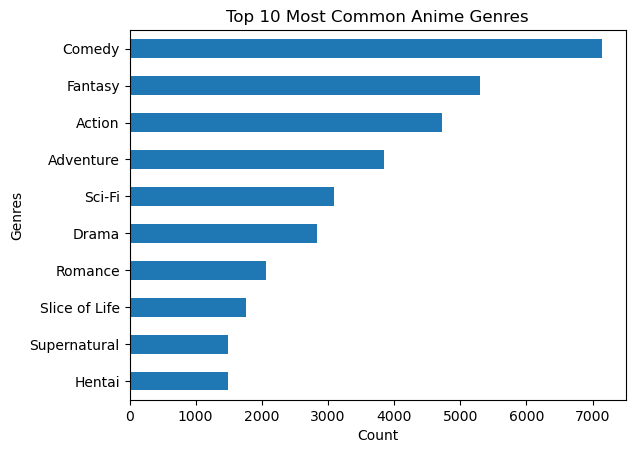

In [5]:
genre_counts = (
    anime["Genres"]
    .dropna()
    .str.split(", ")
    .explode()
)

genre_counts = genre_counts[genre_counts != "UNKNOWN"].value_counts().head(10)
print(genre_counts)

genre_counts.sort_values().plot(kind="barh", title="Top 10 Most Common Anime Genres")
plt.xlabel("Count")
plt.show()


### Answer 2

The most common genres were **Comedy**, **Fantasy**, and **Action**. This shows that the dataset contains a large amount of mainstream and broad-appeal anime. It also suggests that humor, adventure, and fantasy elements are extremely common across anime as a whole.


## Question 3

Do anime with more episodes tend to have higher scores?


               Average_Score  Count
Episode_Group                      
1 episode           6.114042   7289
2-12                6.461922   5062
13-26               6.880679   2048
27-52               6.760012    861
53+                 6.890030    335


C:\Users\zplnd\AppData\Local\Temp\ipykernel_50860\3781706565.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  episode_df.groupby("Episode_Group")


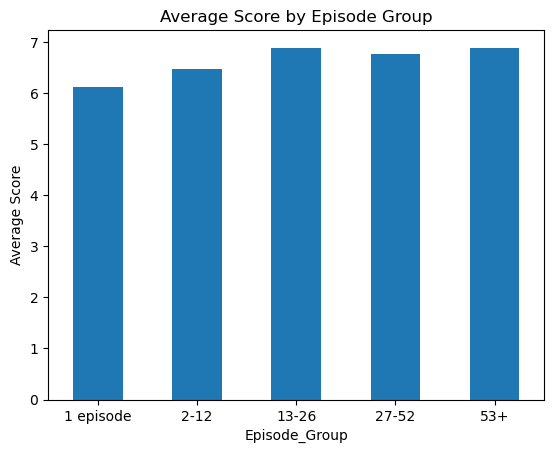

In [6]:
episode_df = anime.dropna(subset=["Score", "Episodes"]).copy()
episode_df = episode_df[(episode_df["Episodes"] > 0) & (episode_df["Episodes"] < 1000)]

episode_df["Episode_Group"] = pd.cut(
    episode_df["Episodes"],
    bins=[0, 1, 12, 26, 52, 1000],
    labels=["1 episode", "2-12", "13-26", "27-52", "53+"],
    include_lowest=True
)

episode_scores = (
    episode_df.groupby("Episode_Group")
    .agg(Average_Score=("Score", "mean"), Count=("Score", "count"))
)

print(episode_scores)

episode_scores["Average_Score"].plot(kind="bar", title="Average Score by Episode Group")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()


### Answer 3

Anime with only **1 episode** had the lowest average score, while anime in the **13-26 episode** and **53+ episode** groups had the highest averages at about **6.88 to 6.89**. This suggests that very short entries, such as single movies or specials, are not rated as strongly on average as longer series. Overall, anime with more episodes tended to score slightly better.


## Question 4

Do anime with more members tend to have higher scores?


Correlation between Score and Members: 0.39092166898759706


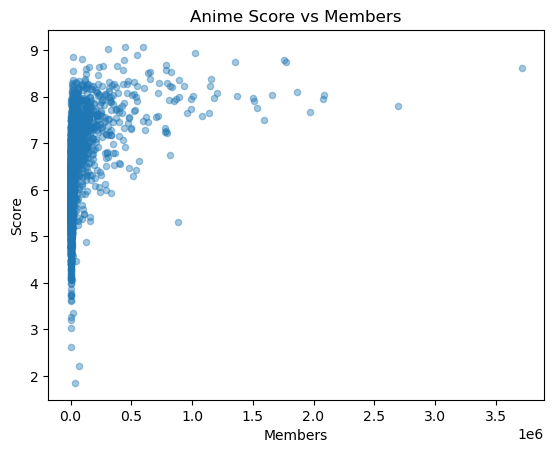

In [7]:
member_df = anime.dropna(subset=["Score", "Members"]).copy()

correlation = member_df["Score"].corr(member_df["Members"])
print("Correlation between Score and Members:", correlation)

member_sample = member_df.sample(3000, random_state=42)

member_sample.plot(
    kind="scatter",
    x="Members",
    y="Score",
    alpha=0.4,
    title="Anime Score vs Members"
)
plt.show()


### Answer 4

The correlation between **Members** and **Score** was about **0.39**, which shows a moderate positive relationship. In general, anime with larger audiences tended to have higher scores. The scatter plot is spread out, so audience size does not completely determine score, but popularity and score are clearly related.


## Question 5

Which source material type has the highest average anime score?


              Average_Score  Count
Source                            
Light novel        6.959065    877
Manga              6.830063   4150
Web manga          6.749270    315
Novel              6.715667    540
4-koma manga       6.656107    280
Mixed media        6.440804    112
Game               6.305921    956
Visual novel       6.296556   1089
Original           6.071355   4545
Other              6.028704    517
Unknown            5.937078   1735
Music              5.663131    313


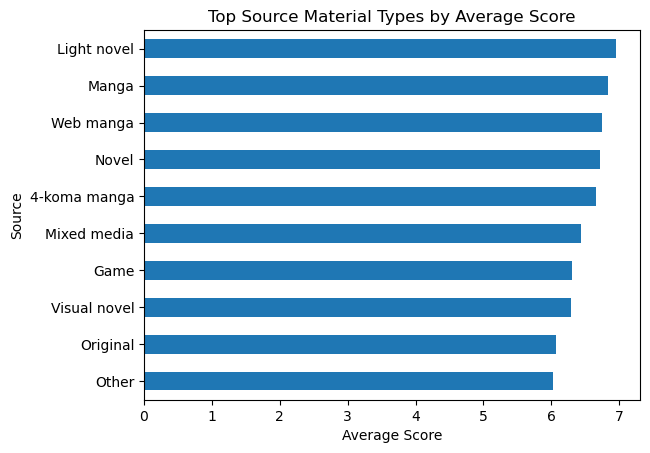

In [8]:
source_scores = (
    anime.dropna(subset=["Score"])
    .groupby("Source")
    .agg(Average_Score=("Score", "mean"), Count=("Score", "count"))
)

source_scores = source_scores[source_scores["Count"] >= 100].sort_values("Average_Score", ascending=False)
print(source_scores)

source_scores["Average_Score"].head(10).sort_values().plot(
    kind="barh",
    title="Top Source Material Types by Average Score"
)
plt.xlabel("Average Score")
plt.show()


### Answer 5

Among source categories with at least 100 anime, **Light novel** adaptations had the highest average score at about **6.96**, followed by **Manga** and **Web manga**. Original anime scored lower on average than several adaptation-based categories. This suggests that anime adapted from written source material, especially light novels and manga, tended to perform better in this dataset.


## Conclusion

This dataset was a strong choice for exploring anime with Pandas because it included both numeric and categorical variables. My analysis showed that TV anime had the highest average scores, Comedy was the most common genre, longer anime tended to score slightly better, higher-member anime usually had better scores, and light novel adaptations had the highest average score among major source types.

Overall, the project showed how Pandas can be used to clean data, group rows, split text into categories, calculate summary statistics, and create clear visualizations from a large real-world dataset.
